# IVFPQ vs. KNN Accuracy and Performance

SCimilarity uses TileDB KNN IVF_FLAT index which provides exact vector similarity search. Cytoverse quantizes the vectors via Product Quantization (PQ) and then performs an approximate lookup based on partitions in an Inverted File Index (IVF) fetched over HTTP.


In [1]:
from pathlib import Path
from typing import Tuple
from collections import Counter
import time
import tracemalloc

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import anndata
import torch

from scimilarity import CellAnnotation
from scimilarity.utils import align_dataset, lognorm_counts

from ivfpq import IVFPQ

In [2]:
# Load a randomly selected subset of the SCimilarity tutorial test file
adata = anndata.read_h5ad("tests/fixtures/GSE136831_subsample_100.h5ad")
print(f"Loaded test data shape: {adata.shape}")
n_queries = adata.shape[0]

k_neighbors = 50

Loaded test data shape: (100, 44942)


## Compute SCimilarity Neighbors via KNN


In [3]:
def get_scimilarity_predictions(
    adata: anndata.AnnData, model_path: Path, k_neighbors: int = 50
) -> Tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray, dict]:
    """
    Get cell type predictions using SCimilarity.

    Returns:
        embeddings: Cell embeddings [n_cells, embedding_dim]
        predictions: Cell type predictions [n_cells]
        nn_idxs: Indices of nearest neighbors [n_cells, k_neighbors]
        nn_dists: Cosine distances to nearest neighbors [n_cells, k_neighbors]
        stats: Statistics about the predictions
    """
    # Load SCimilarity model
    cell_annotation = CellAnnotation(model_path, use_gpu=False)

    # Align and normalize
    adata_aligned = align_dataset(adata, cell_annotation.gene_order)
    adata_normalized = lognorm_counts(adata_aligned)

    # Get embeddings
    embeddings = cell_annotation.get_embeddings(adata_normalized.X)

    # Get predictions
    predictions, nn_idxs, nn_dists, stats = cell_annotation.get_predictions_knn(
        embeddings, k=k_neighbors, disable_progress=True, weighting=True
    )

    return embeddings, predictions, nn_idxs, nn_dists, stats


tracemalloc.start()
start_time = time.time()

embeddings, knn_predictions, knn_idxs, knn_dists, sc_stats = (
    get_scimilarity_predictions(
        adata, "data/models/scimilarity/model_v1.1", k_neighbors=k_neighbors
    )
)
end_time = time.time()

knn_duration = end_time - start_time

knn_current, knn_peak = tracemalloc.get_traced_memory()
tracemalloc.stop()

print(f"KNN execution time: {knn_duration:.4f} seconds")
print(f"Current memory usage: {knn_current / 2**20:.2f} MiB")
print(f"Peak memory usage: {knn_peak / 2**20:.2f} MiB")

KNN execution time: 42.1599 seconds
Current memory usage: 44.63 MiB
Peak memory usage: 1085.54 MiB


## Compute IVFPQ Neighbors


In [8]:
def get_ivfpq_predictions(
    embeddings: np.ndarray,
    model_path: Path,
    reference_labels: pd.DataFrame,
    k_neighbors: int = 50,
    n_partitions_search: int = 4,
) -> Tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray]:
    """
    Get cell type predictions using IVFPQ with batched processing.

    Returns:
        predictions: Predicted cell type labels [n_cells]
        nn_idxs: Indices of nearest neighbors [n_cells, k_neighbors]
        nn_dists: Cosine distances to nearest neighbors [n_cells, k_neighbors]
        nn_labels: Labels of nearest neighbors [n_cells, k_neighbors]
    """

    ivf = IVFPQ.load(model_path)

    predictions = []
    nn_idxs = []
    nn_dists = []
    nn_labels = []

    for embedding in embeddings:
        # Assume normalized so we can compare distances
        assert np.isclose(np.linalg.norm(embedding), 1.0)

        # Convert to torch tensor
        query_vector = torch.from_numpy(embedding).float()

        # Search using IVFPQ
        vector_ids, distances = ivf.search(
            query_vector=query_vector,
            model_path=model_path,
            n_probe=n_partitions_search,
        )

        # Convert distances to cosine distances to compare with SCimilarity
        cosine_distances = np.array(distances) / 2.0

        # Convert to numpy arrays and limit to k_neighbors
        nn_idxs.append(np.array(vector_ids[:k_neighbors]))
        nn_dists.append(np.array(cosine_distances[:k_neighbors]))

        # Get labels for nearest neighbors
        neighbor_labels = []
        for vec_id in vector_ids[:k_neighbors]:  # Ensure we only use k neighbors
            if vec_id < len(reference_labels):
                # Get the "prediction" column from reference labels
                label = reference_labels.iloc[vec_id]["prediction"]
                neighbor_labels.append(label)

        nn_labels.append(neighbor_labels)

        # Vote for most common label (simple majority voting)
        if neighbor_labels:
            label_counts = Counter(neighbor_labels)
            predicted_label = label_counts.most_common(1)[0][0]
        else:
            predicted_label = "Unknown"

        predictions.append(predicted_label)

    print(f"  Processed {len(embeddings)} cells")

    # Stack arrays to create proper 2D numpy arrays
    return (
        np.array(predictions),
        np.vstack(nn_idxs),  # Creates [n_cells, k_neighbors] array
        np.vstack(nn_dists),  # Creates [n_cells, k_neighbors] array
        np.array(nn_labels, dtype=object),
    )


reference_labels = pd.read_parquet("data/references/scimilarity/labels.parquet")

ivfpq_data = {}

n_subs = [8, 16, 32]  # Number of IVF partitions
n_probes = range(1, 11)  # Number of probes to search

for n_sub in n_subs:
    for n_probe in n_probes:
        ivfpq_predictions, ivfpq_idxs, ivfpq_dists, ivfpq_labels = (
            get_ivfpq_predictions(
                embeddings,
                Path(f"data/ivfpq{n_sub}x256"),
                reference_labels=reference_labels,
                k_neighbors=k_neighbors,
                n_partitions_search=n_probe,
            )
        )
        ivfpq_data[(n_sub, n_probe)] = {"ivfpq_idxs": ivfpq_idxs}

  Processed 100 cells
  Processed 100 cells
  Processed 100 cells
  Processed 100 cells
  Processed 100 cells
  Processed 100 cells
  Processed 100 cells
  Processed 100 cells
  Processed 100 cells
  Processed 100 cells
  Processed 100 cells
  Processed 100 cells
  Processed 100 cells
  Processed 100 cells
  Processed 100 cells
  Processed 100 cells
  Processed 100 cells
  Processed 100 cells
  Processed 100 cells
  Processed 100 cells
  Processed 100 cells
  Processed 100 cells
  Processed 100 cells
  Processed 100 cells
  Processed 100 cells
  Processed 100 cells
  Processed 100 cells
  Processed 100 cells
  Processed 100 cells
  Processed 100 cells


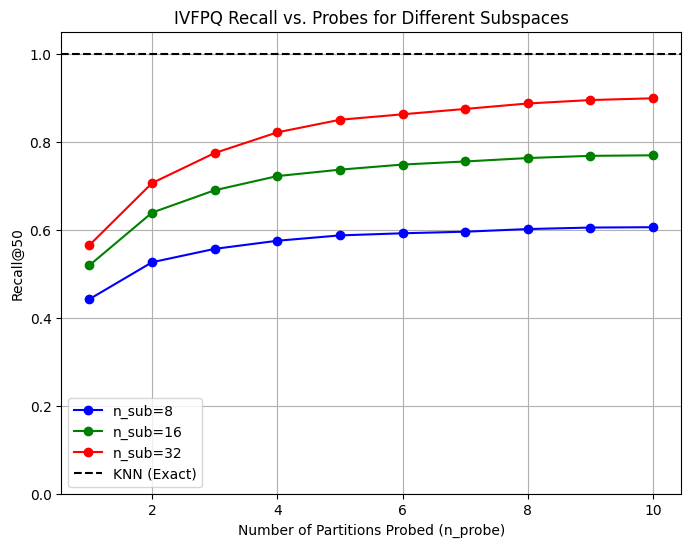

In [9]:
import numpy as np
import matplotlib.pyplot as plt


def compute_recall(knn_idxs, ivfpq_idxs, k):
    """
    Compute mean recall@K: fraction of exact KNN neighbors in IVFPQ results.
    Averages over all queries.
    """
    n_queries = knn_idxs.shape[0]
    recalls = []
    for q in range(n_queries):
        true_set = set(knn_idxs[q])
        approx_set = set(ivfpq_idxs[q])
        intersection = len(true_set & approx_set)
        recalls.append(intersection / k)
    return np.mean(recalls)


def plot_recall_vs_probes(knn_idxs, ivfpq_data, k_neighbors, n_subs, n_probes):
    plt.figure(figsize=(8, 6))
    colors = ["b", "g", "r"]  # One per n_sub

    for i, n_sub in enumerate(n_subs):
        recalls = []
        for n_probe in n_probes:
            key = (n_sub, n_probe)
            if key in ivfpq_data:
                ivfpq_idxs = ivfpq_data[key]["ivfpq_idxs"]
                recall = compute_recall(knn_idxs, ivfpq_idxs, k_neighbors)
                recalls.append(recall)
            else:
                recalls.append(np.nan)  # Skip missing data

        plt.plot(n_probes, recalls, marker="o", color=colors[i], label=f"n_sub={n_sub}")

    # KNN baseline
    plt.axhline(y=1.0, color="k", linestyle="--", label="KNN (Exact)")

    plt.xlabel("Number of Partitions Probed (n_probe)")
    plt.ylabel(f"Recall@{k_neighbors}")
    plt.title("IVFPQ Recall vs. Probes for Different Subspaces")
    plt.legend()
    plt.grid(True)
    plt.ylim(0, 1.05)
    # plt.savefig("recall_vs_probes.png")  # Or plt.show() for display
    plt.show()
    plt.close()


# Example usage (replace with your data)
# knn_idxs = np.array([...])  # Shape: [n_queries, k_neighbors]
# ivfpq_data = {
#     (8,1): {'ivfpq_idxs': np.array([...])},
#     (8,2): {'ivfpq_idxs': np.array([...])},
#     # ... for all combos
# }
plot_recall_vs_probes(
    knn_idxs, ivfpq_data, k_neighbors=k_neighbors, n_subs=n_subs, n_probes=n_probes
)

## Distance Distortion vs. Recall

SCimilarity (get_predictions_knn): Uses cosine distance via hnswlib
IVFPQ (PQDistance): Uses squared Euclidean distance


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Assume sc_dists, sc_idxs, ivfpq_dists, ivfpq_idxs are numpy arrays [n_cells, k_neighbors]
# Normalize distances to [0, 1] to compare cosine and squared Euclidean metrics
sc_dists_normalized = (sc_dists - np.min(sc_dists)) / (
    np.max(sc_dists) - np.min(sc_dists) + 1e-10
)
ivfpq_dists_normalized = (ivfpq_dists - np.min(ivfpq_dists)) / (
    np.max(ivfpq_dists) - np.min(ivfpq_dists) + 1e-10
)


# Calculate Recall @ k
def calculate_recall(sc_idxs, ivfpq_idxs, k):
    recall = []
    for i in range(sc_idxs.shape[0]):
        true_set = set(sc_idxs[i, :k])
        approx_set = set(ivfpq_idxs[i, :k])
        recall.append(len(true_set & approx_set) / k)
    return np.array(recall)


# Calculate distance distortion (mean absolute difference of normalized distances for matching indices)
def calculate_distortion(sc_dists_norm, sc_idxs, ivfpq_dists_norm, ivfpq_idxs, k):
    distortion = []
    for i in range(sc_idxs.shape[0]):
        # Find common indices between true and approximate neighbors
        common_indices = set(sc_idxs[i, :k]) & set(ivfpq_idxs[i, :k])
        if len(common_indices) == 0:
            # If no common indices, use mean absolute difference across all k neighbors
            distortion.append(
                np.mean(np.abs(sc_dists_norm[i, :k] - ivfpq_dists_norm[i, :k]))
            )
        else:
            # Get distances for common indices
            sc_dist_subset = []
            ivfpq_dist_subset = []
            for idx in common_indices:
                sc_pos = np.where(sc_idxs[i, :k] == idx)[0]
                ivfpq_pos = np.where(ivfpq_idxs[i, :k] == idx)[0]
                if len(sc_pos) > 0 and len(ivfpq_pos) > 0:
                    sc_dist_subset.append(sc_dists_norm[i, sc_pos[0]])
                    ivfpq_dist_subset.append(ivfpq_dists_norm[i, ivfpq_pos[0]])
            if len(sc_dist_subset) > 0:
                distortion.append(
                    np.mean(
                        np.abs(np.array(sc_dist_subset) - np.array(ivfpq_dist_subset))
                    )
                )
            else:
                distortion.append(
                    np.mean(np.abs(sc_dists_norm[i, :k] - ivfpq_dists_norm[i, :k]))
                )
    return np.array(distortion)


# Compute metrics for k (default to 10 or max neighbors)
k = min(50, sc_dists.shape[1])
recall_k = calculate_recall(sc_idxs, ivfpq_idxs, k)
distortion = calculate_distortion(
    sc_dists_normalized, sc_idxs, ivfpq_dists_normalized, ivfpq_idxs, k
)

# Create scatter plot
plt.figure(figsize=(8, 6))
plt.scatter(recall_k, distortion, alpha=0.5, s=50, c="blue", edgecolors="k")
plt.xlabel(f"Recall @ {k}")
plt.ylabel("Distance Distortion (Mean Absolute Difference, Normalized)")
plt.title(
    f"Distance Distortion vs. Recall @ {k} per Cell Query (IVF+PQ vs. SCimilarity)"
)
plt.grid(True, linestyle="--", alpha=0.7)
plt.tight_layout()

# Save and show plot
# plt.savefig("distortion_vs_recall_ivfpq.png")
plt.show()

## Recall@k (Intersection-over-k)


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Assume sc_dists, sc_idxs, ivfpq_dists, ivfpq_idxs are numpy arrays [n_cells, k_neighbors]
# Normalize distances to [0, 1] for comparable distortion
sc_dists_normalized = (sc_dists - np.min(sc_dists)) / (
    np.max(sc_dists) - np.min(sc_dists) + 1e-10
)
ivfpq_dists_normalized = (ivfpq_dists - np.min(ivfpq_dists)) / (
    np.max(ivfpq_dists) - np.min(ivfpq_dists) + 1e-10
)


# Calculate standard Recall@k (Intersection-over-k)
def calculate_recall_k(sc_idxs, ivfpq_idxs, k):
    recall = []
    for i in range(sc_idxs.shape[0]):
        true_set = set(sc_idxs[i, :k])
        approx_set = set(ivfpq_idxs[i, :k])
        recall.append(len(true_set & approx_set) / k)
    return np.array(recall)


# Calculate position-weighted recall (Average Precision @ k)
def calculate_ap_k(sc_idxs, ivfpq_idxs, k):
    ap_scores = []
    for i in range(sc_idxs.shape[0]):
        true_set = set(sc_idxs[i, :k])
        approx_indices = ivfpq_idxs[i, :k]
        relevant = 0
        precision_sum = 0
        for rank, idx in enumerate(approx_indices, 1):
            if idx in true_set:
                relevant += 1
                precision_sum += relevant / rank
        ap = precision_sum / k if relevant > 0 else 0
        ap_scores.append(ap)
    return np.array(ap_scores)


# Calculate distance distortion (mean absolute difference of normalized distances for matching indices)
def calculate_distortion(sc_dists_norm, sc_idxs, ivfpq_dists_norm, ivfpq_idxs, k):
    distortion = []
    for i in range(sc_idxs.shape[0]):
        common_indices = set(sc_idxs[i, :k]) & set(ivfpq_idxs[i, :k])
        if len(common_indices) == 0:
            distortion.append(
                np.mean(np.abs(sc_dists_norm[i, :k] - ivfpq_dists_norm[i, :k]))
            )
        else:
            sc_dist_subset = []
            ivfpq_dist_subset = []
            for idx in common_indices:
                sc_pos = np.where(sc_idxs[i, :k] == idx)[0]
                ivfpq_pos = np.where(ivfpq_idxs[i, :k] == idx)[0]
                if len(sc_pos) > 0 and len(ivfpq_pos) > 0:
                    sc_dist_subset.append(sc_dists_norm[i, sc_pos[0]])
                    ivfpq_dist_subset.append(ivfpq_dists_norm[i, ivfpq_pos[0]])
            if len(sc_dist_subset) > 0:
                distortion.append(
                    np.mean(
                        np.abs(np.array(sc_dist_subset) - np.array(ivfpq_dist_subset))
                    )
                )
            else:
                distortion.append(
                    np.mean(np.abs(sc_dists_norm[i, :k] - ivfpq_dists_norm[i, :k]))
                )
    return np.array(distortion)


# Compute metrics for k (default to 10 or max neighbors)
k = sc_dists.shape[1]
recall_k = calculate_recall_k(sc_idxs, ivfpq_idxs, k)
ap_k = calculate_ap_k(sc_idxs, ivfpq_idxs, k)
distortion = calculate_distortion(
    sc_dists_normalized, sc_idxs, ivfpq_dists_normalized, ivfpq_idxs, k
)

# Create subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Plot 1: Distortion vs. Recall@k
ax1.scatter(recall_k, distortion, alpha=0.5, s=50, c="blue", edgecolors="k")
ax1.set_xlabel(f"Recall @ {k} (Intersection-over-k)")
ax1.set_ylabel("Distance Distortion (Mean Absolute Difference, Normalized)")
ax1.set_title(f"Distortion vs. Recall @ {k} (IVF+PQ vs. Exhaustive)")
ax1.grid(True, linestyle="--", alpha=0.7)

# Plot 2: Distortion vs. Position-weighted Recall (AP@k)
ax2.scatter(ap_k, distortion, alpha=0.5, s=50, c="green", edgecolors="k")
ax2.set_xlabel(f"Average Precision @ {k}")
ax2.set_ylabel("Distance Distortion (Mean Absolute Difference, Normalized)")
ax2.set_title(f"Distortion vs. AP @ {k} (IVF+PQ vs. Exhaustive)")
ax2.grid(True, linestyle="--", alpha=0.7)

plt.tight_layout()

# Save and show plot
plt.savefig("distortion_vs_recall_metrics.png")
plt.show()

# Print mean Recall@k and mean AP@k
print(f"Mean Recall @ {k}: {np.mean(recall_k):.4f}")
print(f"Mean AP @ {k}: {np.mean(ap_k):.4f}")